In [6]:
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt

path = "results/stationary_seed42_A4_T1000.npz"
data = np.load(path, allow_pickle=True)

meta = json.loads(data["meta"].item())
print(meta)
print(data)

df = pd.DataFrame({
    "t": data["t"],
    "agent_move": data["agent_move"],
    "opp_move": data["opp_move"],
    "r_agent": data["r_agent"],
    "r_opp": data["r_opp"],
    "att_est_before": data["att_est_before"],
    "bel_est_before": data["bel_est_before"],
    "att_est_after": data["att_est_after"],
    "bel_est_after": data["bel_est_after"],
    "true_error": data["true_error"],
    "prob_true": data["prob_true"],
    "prob_est": data["prob_est"],
    "error_est": data["error_est"],
})

df.head()


{'scenario': 'stationary', 'seed': 42, 'T': 1000, 'n_actions': 4, 'opp_att_true': 1.0, 'opp_bel_true': 0.10230513964028178, 'opp_nash_true': 5}
NpzFile 'results/stationary_seed42_A4_T1000.npz' with keys: t, agent_move, opp_move, r_agent, r_opp...


,t,agent_move,opp_move,r_agent,r_opp,att_est_before,bel_est_before,att_est_after,bel_est_after,true_error,prob_true,prob_est,error_est
0,0,0,2,0.858598,0.827631,-0.032271,0.124179,0.056020,0.152994,0.945340,1.0,1.000000,0.2
1,1,2,1,0.832678,0.568741,0.056020,0.152994,0.073289,0.756382,1.134288,1.0,1.000000,0.2
2,2,3,3,0.783898,0.630283,0.073289,0.756382,0.057130,0.828638,1.190194,1.0,1.000000,0.2
3,3,3,1,0.902602,0.493991,0.057130,0.828638,-0.063939,0.352948,1.093064,1.0,1.000000,0.2
4,4,0,3,0.925120,0.520672,-0.063939,0.352948,-0.103227,0.390673,1.140292,1.0,0.542605,0.2


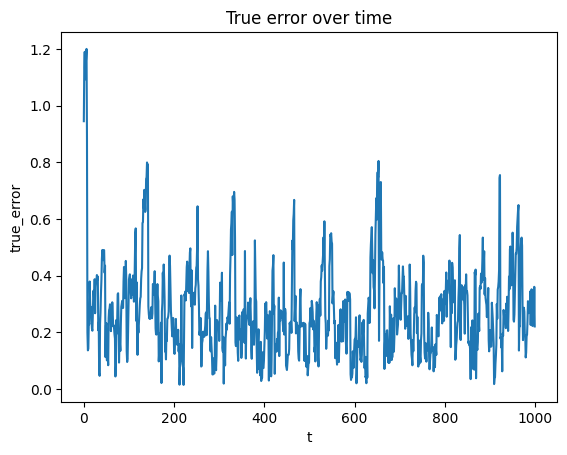

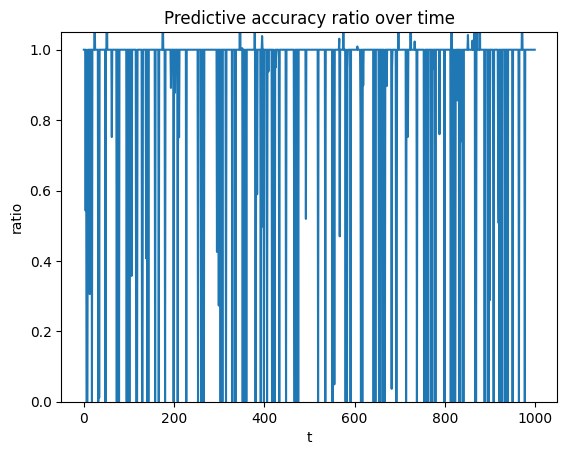

In [7]:
plt.figure()
plt.plot(df["t"], df["true_error"])
plt.title("True error over time")
plt.xlabel("t")
plt.ylabel("true_error")
plt.show()

plt.figure()
plt.plot(df["t"], df["prob_est"] / (df["prob_true"] + 1e-12))
plt.title("Predictive accuracy ratio over time")
plt.xlabel("t")
plt.ylabel("ratio")
plt.ylim(0, 1.05)
plt.show()


In [8]:
import os, glob, json
import numpy as np
import matplotlib.pyplot as plt

def _load_npz_runs(results_dir: str, n_actions: int, T: int):
    """Return a list of dicts: {'path', 'meta', 'data'} for runs matching (n_actions, T)."""
    paths = sorted(glob.glob(os.path.join(results_dir, "*.npz")))
    runs = []
    for p in paths:
        data = np.load(p, allow_pickle=True)
        meta = json.loads(data["meta"].item())
        if int(meta.get("n_actions", -1)) == int(n_actions) and int(meta.get("T", -1)) == int(T):
            runs.append({"path": p, "meta": meta, "data": data})
    return runs

def _stack_series(runs, key: str, T: int):
    """Stack a time-series key into array shape (n_runs, T). Skips runs with wrong length."""
    series = []
    kept = []
    for r in runs:
        arr = np.asarray(r["data"][key], dtype=float)
        if arr.shape[0] == T:
            series.append(arr)
            kept.append(r)
    if not series:
        return None, []
    return np.stack(series, axis=0), kept

def plot_aggregated(results_dir: str = "results", n_actions: int = 4, T: int = 1000, eps: float = 1e-12):
    """
    Load all .npz runs matching (n_actions, T) and plot aggregated curves:
    - true_error (mean ± std)
    - predictive accuracy ratio (mean ± std), where ratio = prob_est / (prob_true + eps)
    - att_est_after, bel_est_after (mean ± std)
    - error_est (mean ± std) if available
    """
    runs = _load_npz_runs(results_dir, n_actions, T)
    if not runs:
        print(f"[INFO] No runs found for n_actions={n_actions}, T={T} in '{results_dir}'.")
        return

    print(f"[INFO] Found {len(runs)} runs for n_actions={n_actions}, T={T}.")
    for r in runs[:5]:
        print(f"  - {os.path.basename(r['path'])} (seed={r['meta'].get('seed')})")
    if len(runs) > 5:
        print(f"  ... and {len(runs)-5} more")

    t = np.arange(T)

    # --- True error ---
    true_err, runs_kept = _stack_series(runs, "true_error", T)
    if true_err is None:
        print("[WARN] Could not stack 'true_error' (no valid runs with matching length).")
        return

    mean_true = true_err.mean(axis=0)
    std_true = true_err.std(axis=0)

    plt.figure()
    plt.plot(t, mean_true)
    plt.fill_between(t, mean_true - std_true, mean_true + std_true, alpha=0.2)
    plt.title(f"True error (mean ± std) | n_actions={n_actions}, T={T}, runs={true_err.shape[0]}")
    plt.xlabel("t")
    plt.ylabel("true_error")
    plt.show()

    # --- Predictive accuracy ratio ---
    p_true, _ = _stack_series(runs_kept, "prob_true", T)
    p_est, _ = _stack_series(runs_kept, "prob_est", T)
    if p_true is not None and p_est is not None:
        ratio = p_est / (p_true + eps)
        ratio = np.clip(ratio, 0.0, 1.0)  # consistent with earlier metric choice
        mean_ratio = ratio.mean(axis=0)
        std_ratio = ratio.std(axis=0)

        plt.figure()
        plt.plot(t, mean_ratio)
        plt.fill_between(t, mean_ratio - std_ratio, mean_ratio + std_ratio, alpha=0.2)
        plt.title(f"Predictive accuracy ratio (mean ± std) | n_actions={n_actions}, T={T}")
        plt.xlabel("t")
        plt.ylabel("ratio")
        plt.ylim(0, 1.05)
        plt.show()
    else:
        print("[WARN] Missing 'prob_true' or 'prob_est' in saved runs; skipping ratio plot.")

    # --- Estimated attitude / belief (after update) ---
    att, _ = _stack_series(runs_kept, "att_est_after", T)
    bel, _ = _stack_series(runs_kept, "bel_est_after", T)
    if att is not None:
        plt.figure()
        m = att.mean(axis=0); s = att.std(axis=0)
        plt.plot(t, m)
        plt.fill_between(t, m - s, m + s, alpha=0.2)
        plt.title(f"Estimated opponent attitude (after update) | n_actions={n_actions}, T={T}")
        plt.xlabel("t")
        plt.ylabel("att_est_after")
        plt.show()

    if bel is not None:
        plt.figure()
        m = bel.mean(axis=0); s = bel.std(axis=0)
        plt.plot(t, m)
        plt.fill_between(t, m - s, m + s, alpha=0.2)
        plt.title(f"Estimated opponent belief (after update) | n_actions={n_actions}, T={T}")
        plt.xlabel("t")
        plt.ylabel("bel_est_after")
        plt.show()

    # --- Estimated error (if present) ---
    err_est, _ = _stack_series(runs_kept, "error_est", T)
    if err_est is not None:
        plt.figure()
        m = err_est.mean(axis=0); s = err_est.std(axis=0)
        plt.plot(t, m)
        plt.fill_between(t, m - s, m + s, alpha=0.2)
        plt.title(f"Estimated error (mean ± std) | n_actions={n_actions}, T={T}")
        plt.xlabel("t")
        plt.ylabel("error_est")
        plt.show()
    else:
        print("[INFO] No 'error_est' in runs (or wrong length); skipping estimated-error plot.")


[INFO] Found 10 runs for n_actions=4, T=1000.
  - stationary_seed40_A4_T1000.npz (seed=40)
  - stationary_seed41_A4_T1000.npz (seed=41)
  - stationary_seed42_A4_T1000.npz (seed=42)
  - stationary_seed43_A4_T1000.npz (seed=43)
  - stationary_seed44_A4_T1000.npz (seed=44)
  ... and 5 more


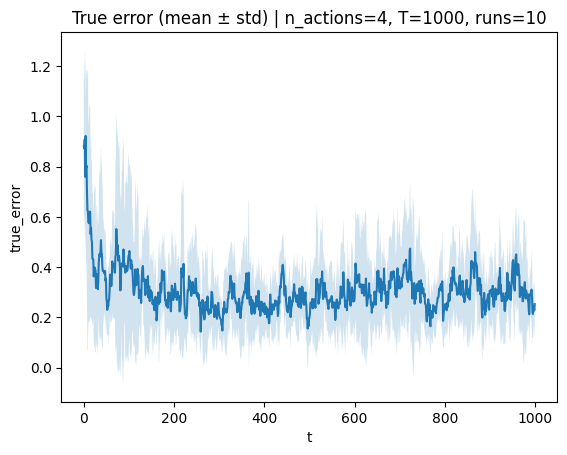

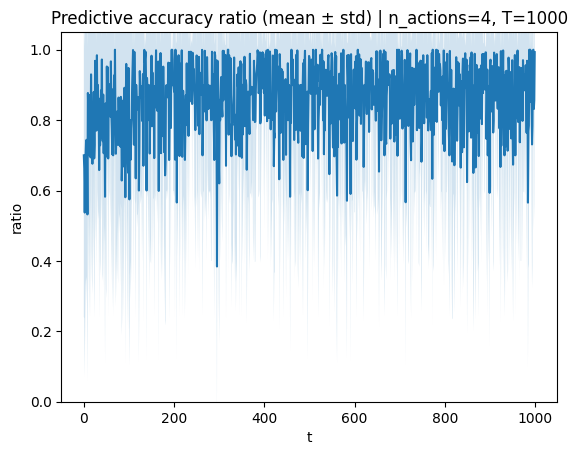

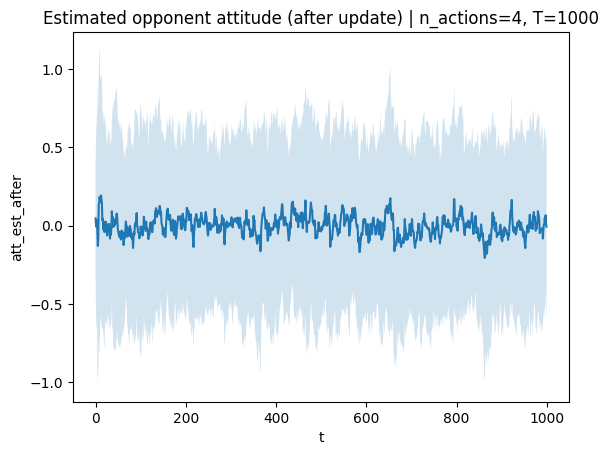

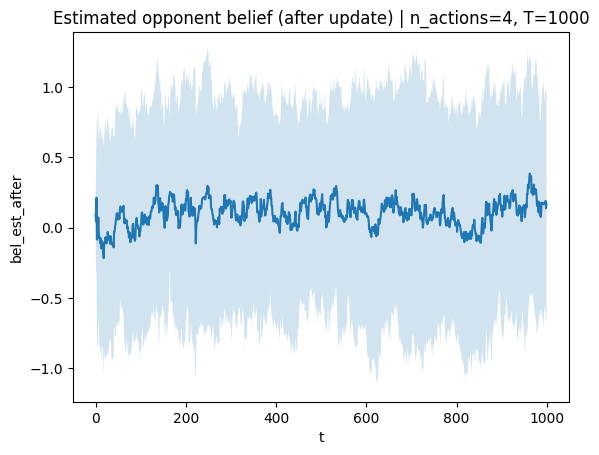

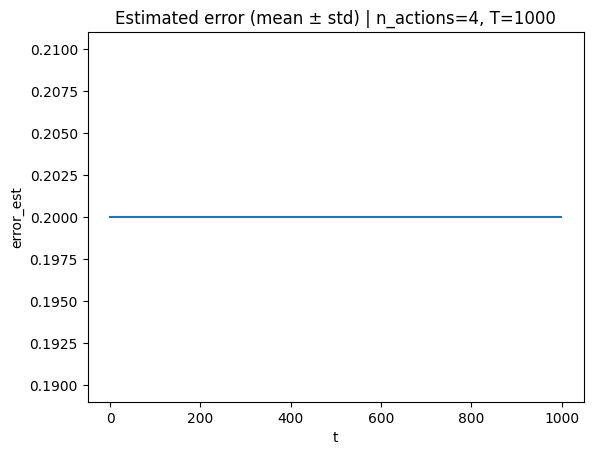

In [9]:
plot_aggregated(results_dir="results", n_actions=4, T=1000)
